<a href="https://colab.research.google.com/github/SaiSiri05/MachineLearning_Labs/blob/main/AIML_Lab2(Statistics_%26_Probability).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns

import plotly.graph_objects as pg
import plotly.express as px

In [8]:
def toss_coin(number_of_tosses=100000):
    return pd.Series(np.random.choice(['Heads', 'Tails'], number_of_tosses))

def throw_dice(number_of_tosses=100000):
    return pd.Series(np.random.randint(1, 6+1, number_of_tosses))

In [9]:
results = throw_dice()

print(results.value_counts())

fig = pg.Figure([
    pg.Bar(
        x=results.value_counts().keys(),
        y=results.value_counts().values
    )
])

fig.show()

3    16860
5    16798
4    16728
6    16599
2    16575
1    16440
Name: count, dtype: int64


In [14]:
results = pd.Series([
    np.sum(throw_dice(20) == 3) for _ in range(1000)
])

fig = pg.Figure([
    pg.Bar(
        x=results.value_counts().keys(),
        y=results.value_counts().values
    )
])

fig.show()

In [17]:
results = pd.Series([np.sum(toss_coin(1000) == 'Tails') for _ in range(1000)])
fig = pg.Figure([pg.Bar(x=results.value_counts().keys(),
                        y=results.value_counts().values)])
fig.show()

In [21]:
results = {shots: toss_coin(shots) for shots in [10, 100, 1000, 10000, 1000000]}
fig = pg.Figure([pg.Bar(x=result.value_counts().keys(),
                        y=result.value_counts().values / shots,)
                    for shots, result in results.items()])
fig.add_shape(type='line', x0=0.5, y0=1/6, x1=6.5, y1=1/6, line=dict(color='Black',))
fig.show()

In [30]:
deck = ['A','K','Q','J']*4 + list(map(str, np.repeat(range(2,11),4)))

trials = 100000
draws = np.random.choice(deck, trials)

results = pd.Series(draws).isin([str(i) for i in range(2,11)])

print("Probability:", results.mean())

Probability: 0.6929


In [34]:
deck = ['A','K','Q','J']*4 + [str(i) for i in range(2,11)]*4

trials = 100000
results = []

for _ in range(trials):
    card1 = np.random.choice(deck)
    card2 = np.random.choice(deck)

    if (card1 not in ['A','K','Q','J']) and (card2 not in ['A','K','Q','J']):
        results.append(1)
    else:
        results.append(0)

print("Probability:", np.mean(results))

Probability: 0.47882


In [25]:
trials = 100000

results = []

for _ in range(trials):
    shuffled_deck = deck.copy()
    np.random.shuffle(shuffled_deck)

    card1 = shuffled_deck.pop()
    card2 = shuffled_deck.pop()

    if (card1 in range(2,11)) and (card2 in range(2,11)):
        results.append(1)
    else:
        results.append(0)

print("Probability:", np.mean(results))

Probability: 0.47706


In [32]:
# create ordered deck
deck = []
suits = ['S','H','D','C']

for suit in suits:
    deck += ['A','2','3','4','5','6','7','8','9','10','J','Q','K']

trials = 100000

results = []

for _ in range(trials):

    cut_position = np.random.randint(1,52)
    bottom_card = deck[cut_position-1]

    if bottom_card in ['2','3','4','5','6','7','8','9','10']:
        results.append(1)
    else:
        results.append(0)

print("Probability:", np.mean(results))

Probability: 0.70633


In [36]:
def number_of_numbered_cards_drawn_before_ace(trials=1000, show_trials=10):
    values = ['A', '2', '3', '4', '5', '6', '7', '8', '9', '10', 'J', 'Q', 'K']
    ranks = ['H', 'D', 'C', 'S']

    cards_thrown_counts = []
    for experiment in range(trials):
        deck_of_cards = [value + rank for value in values for rank in ranks]
        cards_thrown = 0
        cards_pile = []
        while len(deck_of_cards) > 0:
            picked_card = np.random.choice(deck_of_cards)
            cards_pile.append(picked_card)
            if picked_card[0] == 'A':
                break
            cards_thrown += 1
            deck_of_cards.remove(picked_card)
        if experiment < show_trials:
            print(cards_thrown, 'cards were thrown:', ' '.join(cards_pile))
        cards_thrown_counts.append(cards_thrown)

    return np.mean(cards_thrown_counts), cards_thrown_counts

expected_cards_thrown, cards_thrown_counts = number_of_numbered_cards_drawn_before_ace(10000)
print(f'\n{expected_cards_thrown} cards are tossed before we see the first ace!')

30 cards were thrown: 6C 4D 9D 2C QC QS 2S 6S 7S 4C 7C 3D 5C QH 10S 4S JD 2D 8S 9H 8C JC 10C JS 10H 6H 5D KD 3S KC AD
3 cards were thrown: QH 3D 3S AD
7 cards were thrown: 6C 5H QS 6D 10C 7H KD AH
12 cards were thrown: 2S 4S 4H 3C 6S 2H 7H 2C 5S 7S 3S 4D AH
0 cards were thrown: AD
1 cards were thrown: 8C AH
14 cards were thrown: 7S 8D 4C 3S 2C KC 9D 2S 10H 8H 6D 2H QH 6C AS
6 cards were thrown: 5H 5C 6H 8C 2H JC AC
6 cards were thrown: KS 2D 4D 10H 9S 5H AH
1 cards were thrown: 6D AS

9.6239 cards are tossed before we see the first ace!


In [37]:
results = pd.Series(cards_thrown_counts)
fig = pg.Figure([pg.Bar(x=results.value_counts().keys(),
                        y=results.value_counts().values)])
fig.show()

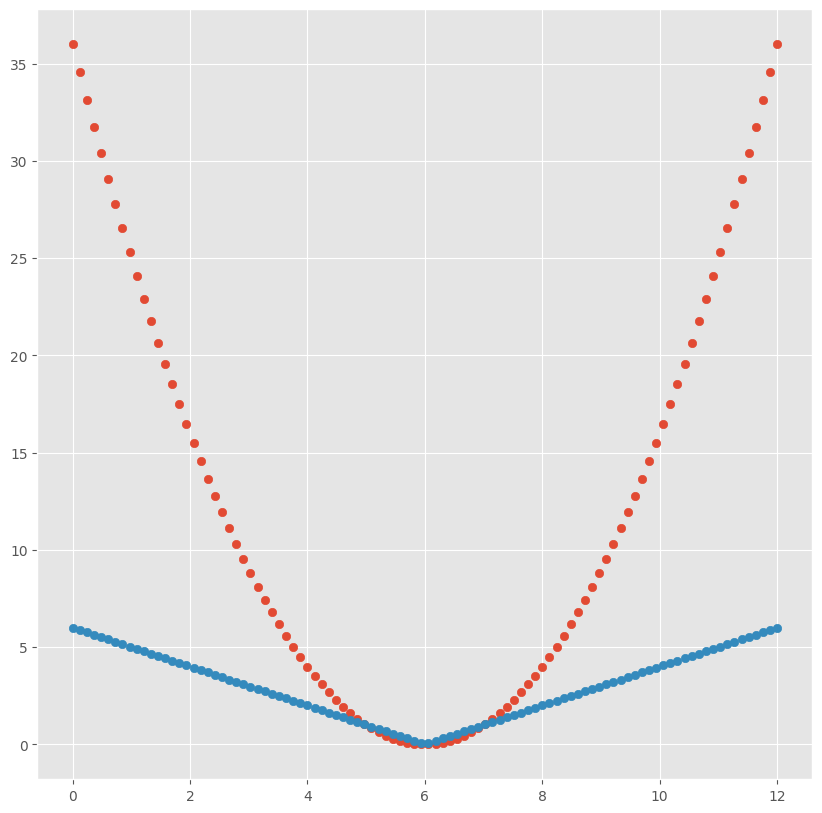

In [39]:
from matplotlib import pyplot as plt
plt.style.use('ggplot')
plt.figure(figsize=(10, 10))

measurements = np.linspace(0, 12, 100)
plt.scatter(measurements, (measurements - 6) ** 2, label='Squared Error')
plt.scatter(measurements, abs(measurements - 6), label='Absolute Error')
plt.show()

(26, 4)


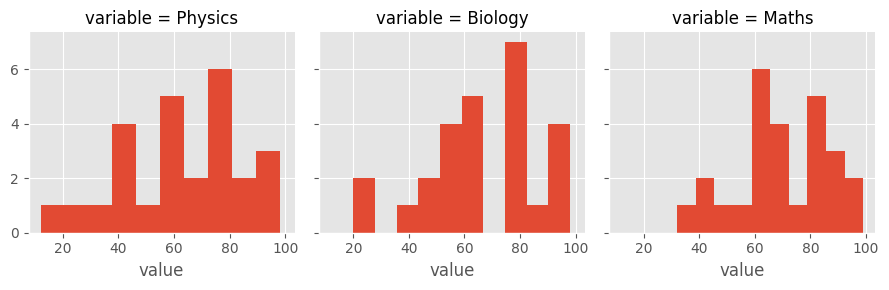

In [41]:
grades = pd.read_csv("https://archive.org/download/ml-fundamentals-data/machine-learning-fundamentals-data/grades.csv")
print(grades.shape)

# Select only numeric columns
grades.select_dtypes(include="number").agg(["mean", "var", "std"])


g = sns.FacetGrid(grades.melt("Name"), col="variable")
g.map(plt.hist, "value")

In [46]:
grades["Physics_std"] = (grades["Physics"] - grades["Physics"].mean()) / grades["Physics"].std()
grades["Maths_std"] = (grades["Maths"] - grades["Maths"].mean()) / grades["Maths"].std()
grades["Biology_std"] = (grades["Biology"] - grades["Biology"].mean()) / grades["Biology"].std()

grades.head()

,Name,Physics,Biology,Maths,Physics_std,Maths_std,Biology_std
0,Arnold,80,78,70,0.713673,0.013309,0.512895
1,Bob,60,98,45,-0.165735,-1.428471,1.448703
2,Cassandra,34,56,65,-1.308965,-0.275047,-0.516494
3,Donovan,56,65,32,-0.341616,-2.178196,-0.095380
4,Emily,98,23,55,1.505141,-0.851759,-2.060577


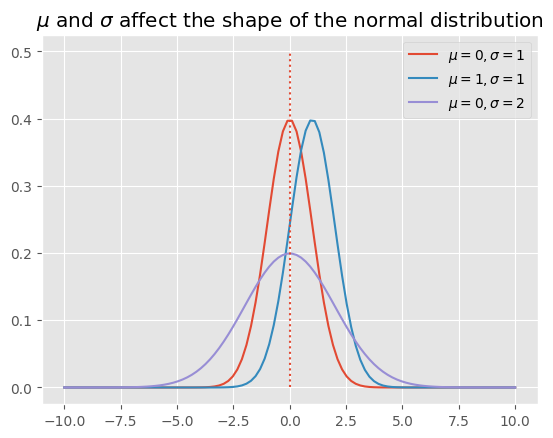

In [47]:
from scipy.stats import norm


import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

x = np.linspace(-10, 10, 100)
f1 = norm.pdf(x, loc=0, scale=1)
f2 = norm.pdf(x, loc=1, scale=1)
f3 = norm.pdf(x, loc=0, scale=2)

plt.plot(x, f1, label=r"$\mu=0, \sigma=1$")
plt.plot(x, f2, label=r"$\mu=1, \sigma=1$")
plt.plot(x, f3, label=r"$\mu=0, \sigma=2$")
plt.vlines(x=0, ymin=0, ymax=0.5, linestyles="dotted")

plt.legend()
plt.title(r"$\mu$ and $\sigma$ affect the shape of the normal distribution")
plt.show()


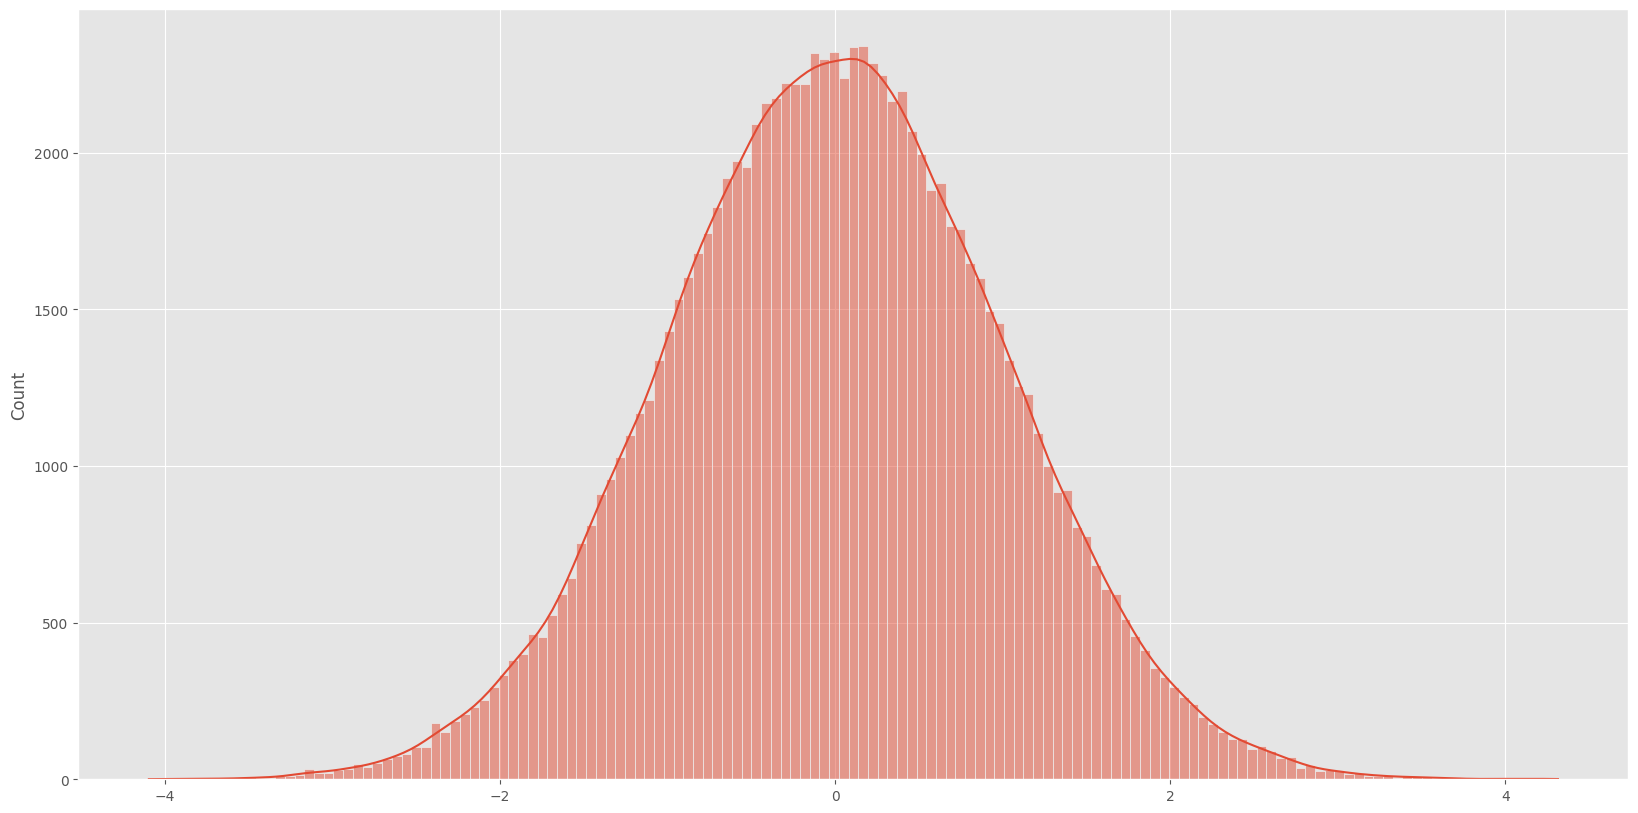

In [50]:
import seaborn as sns
plt.figure(figsize=(20, 10))
x = np.random.normal(size=(100000))
sns.histplot(x, kde=True)
plt.show()

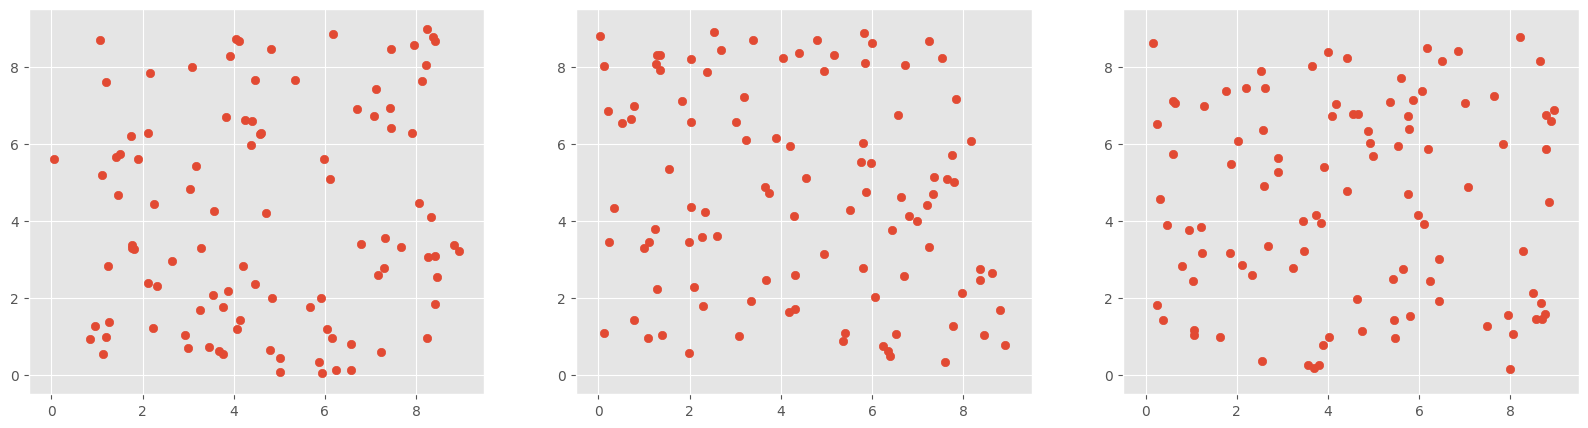

In [51]:
fix, axs = plt.subplots(1, 3, figsize=(20, 5))

for ax in axs:
    x, y = np.random.random(100) * 9, np.random.random(100) * 9
    ax.scatter(x.ravel(), y.ravel())
    ax.set_xlim(-0.5, 9.5)
    ax.set_ylim(-0.5, 9.5)

plt.show()

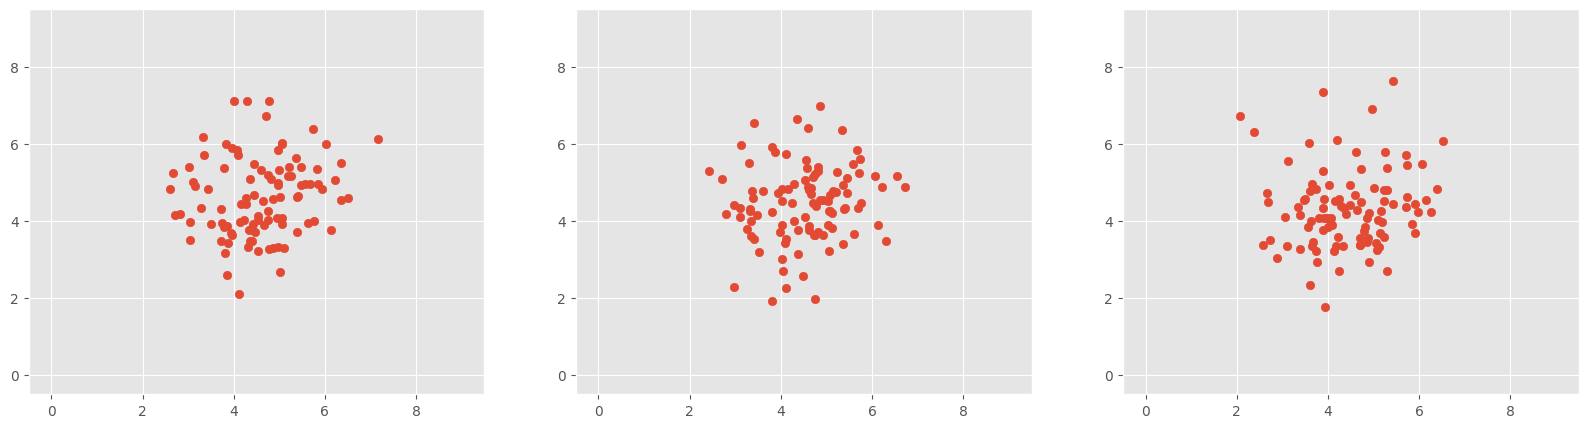

In [52]:
fix, axs = plt.subplots(1, 3, figsize=(20, 5))

for ax in axs:
    x, y = np.random.normal(loc=4.5, scale=1.0, size=100), np.random.normal(loc=4.5, scale=1.0, size=100)
    ax.scatter(x.ravel(), y.ravel())
    ax.set_xlim(-0.5, 9.5)
    ax.set_ylim(-0.5, 9.5)

plt.show()